In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

RESULTS_DIR = 'results'
FIGURES_DIR = 'figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Results will be written under  ./{RESULTS_DIR}/")
print(f"Figures will be written under  ./{FIGURES_DIR}/")

Results will be written under  ./results/
Figures will be written under  ./figures/


In [2]:
SEED = 11
PLOT_TMAX = 800

rng = np.random.default_rng(SEED)
n = 8


def make_strongly_connected(n, p, rng):
    while True:
        A = (rng.random((n, n)) < p) & ~np.eye(n, dtype=bool)
        reach = A.copy()
        for _ in range(n):
            reach = reach | (reach @ reach)
        if reach.all():
            return A

In [3]:
A = make_strongly_connected(n, p=0.45, rng=rng)
edges = [(i, j) for i in range(n) for j in range(n) if A[i, j]]
sigma = {e: float(rng.uniform(1.5, 1.9)) for e in edges}
I = {e: float(rng.uniform(0.55, 0.80)) for e in edges}
eta_max = max(sigma[e] * I[e] for e in edges)

B = rng.uniform(0, 1, size=n)
T = PLOT_TMAX
schedule = rng.integers(0, len(edges), size=T)
history = [B.copy()]
for k in schedule:
    i, j = edges[k]
    B = B.copy()
    B[j] = float(np.clip(B[j] + sigma[edges[k]] * (B[i] - B[j]) * I[edges[k]],
                         0.0, 1.0))
    history.append(B)
history = np.array(history)
final_value = float(history[-1, 0])
print(f"|E| = {len(edges)}, eta_max = {eta_max:.3f}, "
      f"final = {final_value:.4f}")

|E| = 30, eta_max = 1.360, final = 0.3999


Saved ./figures/M_beyond_bound.{png,pdf}


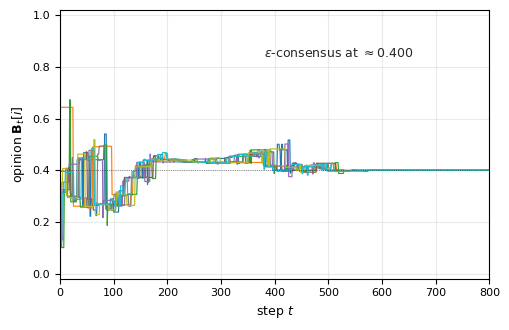

In [4]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(5.2, 3.4))
colors = plt.cm.tab10(np.linspace(0, 1, n))
for k in range(n):
    ax.plot(range(PLOT_TMAX + 1), history[:PLOT_TMAX + 1, k],
            lw=0.85, color=colors[k])
ax.axhline(final_value, color="black", lw=0.6, ls=":", alpha=0.55)
ax.text(PLOT_TMAX * 0.65, 0.85,
        rf"$\varepsilon$-consensus at $\approx {final_value:.3f}$",
        ha="center", va="center", fontsize=9, alpha=0.85)
ax.set_xlim(0, PLOT_TMAX)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel(r"step $t$", fontsize=9)
ax.set_ylabel(r"opinion $\mathbf{B}_t[i]$", fontsize=9)
ax.tick_params(labelsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("./figures/M_beyond_bound.png", dpi=160,
            bbox_inches="tight")
plt.savefig("./figures/M_beyond_bound.pdf",
            bbox_inches="tight")
print("Saved ./figures/M_beyond_bound.{png,pdf}")